# Import the required libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Generate numerical data

In [ ]:
# Set seed so results are reproducible
np.random.seed(42)

# Generate input values
X = np.random.uniform(0, 10, 200)

# Generate output values
#noise = np.random.normal(0, 1, 200)
y = 3 * X + 2

# Check the first few values
print("First 10 input values:")
print(X[:10])

print("\nFirst 10 output values:")
print(y[:10])

First 10 input values:
[3.74540119 9.50714306 7.31993942 5.98658484 1.5601864  1.5599452
 0.58083612 8.66176146 6.01115012 7.08072578]

First 10 output values:
[13.23620357 30.52142919 23.95981825 19.95975453  6.68055921  6.67983561
  3.74250837 27.98528437 20.03345035 23.24217733]


# Visualize the generated data

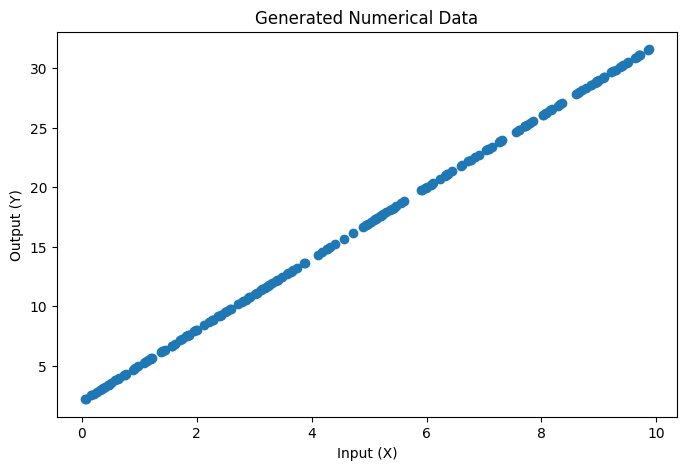

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(X, y)

plt.xlabel("Input (X)")
plt.ylabel("Output (Y)")
plt.title("Generated Numerical Data")

plt.show()

# Reshape the input data

In [ ]:
X = X.reshape(-1, 1)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (200, 1)
Shape of y: (200,)


# Split data into training and testing data

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (160, 1)
Testing data: (40, 1)


# Build the neural network

In [ ]:
model = Sequential([
    Dense(16, activation="relu", input_shape=(1,)),
    Dense(16, activation="relu"),
    Dense(1)
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

# Compile the model

In [ ]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

print("Model compiled successfully.")

Model compiled successfully.


# Train the model

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

# Plot the loss curve

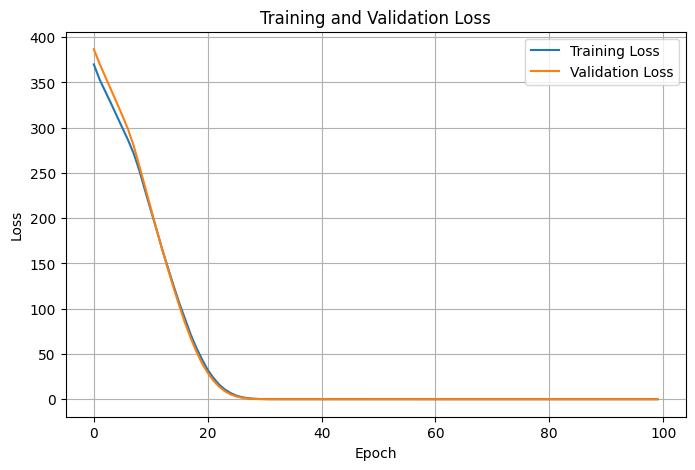

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

# Evaluate the model on unseen test data

In [ ]:
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)

print("Test Loss:", test_loss)
print("Test MAE:", test_mae)

Test Loss: 0.011755106970667839
Test MAE: 0.09196875989437103


# Make predictions on unseen inputs

In [ ]:
y_pred = model.predict(X_test)

# Convert predictions from 2D to 1D
y_pred = y_pred.flatten()

print("First 10 actual values:")
print(y_test[:10])

print("\nFirst 10 predicted values:")
print(y_pred[:10])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
First 10 actual values:
[16.81386789  7.5021353  20.22634556  9.12912632  2.20856392 28.14381771
 31.6066081  22.32693086 21.35518371 21.87566853]

First 10 predicted values:
[16.766306   7.352076  20.216345   8.996976   1.9998326 28.220968
 31.721876  22.340054  21.357609  21.883823 ]


# Actual vs Predicted graph

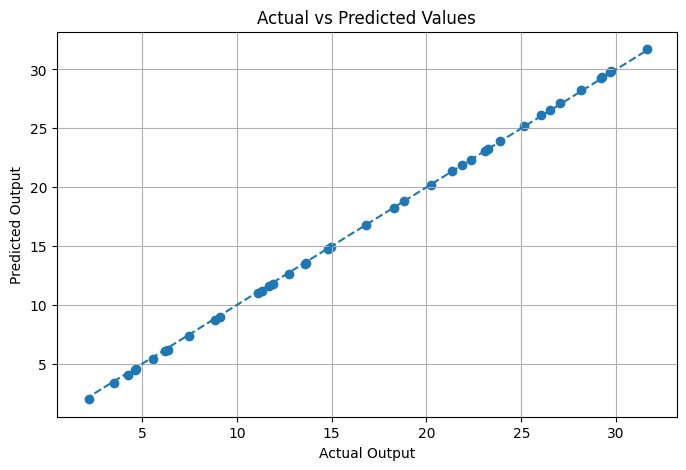

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

# Ideal prediction line
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Output")
plt.ylabel("Predicted Output")
plt.title("Actual vs Predicted Values")

plt.grid(True)
plt.show()

# Calculate R² score

In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.9998494095450771


# Display some actual vs predicted values



In [ ]:
print("Actual vs Predicted")
print("--------   ---------")

for actual, predicted in zip(y_test[:10], y_pred[:10]):
    print(f"Actual: {actual:.2f}   Predicted: {predicted:.2f}")

Actual vs Predicted
--------   ---------
Actual: 16.81   Predicted: 16.77
Actual: 7.50   Predicted: 7.35
Actual: 20.23   Predicted: 20.22
Actual: 9.13   Predicted: 9.00
Actual: 2.21   Predicted: 2.00
Actual: 28.14   Predicted: 28.22
Actual: 31.61   Predicted: 31.72
Actual: 22.33   Predicted: 22.34
Actual: 21.36   Predicted: 21.36
Actual: 21.88   Predicted: 21.88
